# SaaS Business Analytics - Python / Jupyter Notebook

This notebook analyzes a synthetic SaaS company's data: customers, subscriptions,
monthly usage, and payments. It reads from the same `saas.db` SQLite database used
in `analysis_queries.sql`, so SQL and Python tell the same story.

**What this notebook covers**
1. Load data (SQL → pandas)
2. Monthly Recurring Revenue (MRR) and growth
3. Churn rate over time
4. Revenue by plan, industry, and acquisition channel
5. Cohort retention analysis
6. Customer Lifetime Value (LTV) estimate
7. At-risk customer list
8. Exporting a summary back out for the Excel workbook

Run cells top to bottom with **Shift+Enter**.

In [1]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

conn = sqlite3.connect("saas.db")
pd.set_option("display.max_columns", None)
print("Connected to saas.db")

Connected to saas.db


## 1. Load the raw tables

In [2]:
customers = pd.read_sql("SELECT * FROM customers", conn, parse_dates=["signup_date"])
subscriptions = pd.read_sql("SELECT * FROM subscriptions", conn, parse_dates=["start_date", "end_date"])
usage = pd.read_sql("SELECT * FROM usage", conn, parse_dates=["month"])
payments = pd.read_sql("SELECT * FROM payments", conn, parse_dates=["month"])

print("customers:", customers.shape)
print("subscriptions:", subscriptions.shape)
print("usage:", usage.shape)
print("payments:", payments.shape)
customers.head()

customers: (600, 8)
subscriptions: (600, 7)
usage: (7191, 7)
payments: (7191, 5)


,customer_id,company_name,industry,country,employee_size,acquisition_channel,signup_date,initial_plan
0,CUST0001,"Rodriguez, Figueroa and Sanchez",E-commerce,Germany,25,Paid Ads,2025-01-01,Growth
1,CUST0002,Doyle Ltd,FinTech,Singapore,5,Outbound Sales,2024-10-01,Starter
2,CUST0003,"Mcclain, Miller and Henderson",E-commerce,United Kingdom,25,Paid Ads,2025-01-01,Starter
3,CUST0004,Davis and Sons,E-commerce,Singapore,25,Partner,2024-06-01,Growth
4,CUST0005,"Guzman, Hoffman and Baldwin",Logistics,France,25,Content Marketing,2025-08-01,Growth


## 2. Monthly Recurring Revenue (MRR) and growth rate

Same logic as query #2/#3 in `analysis_queries.sql`, computed here in pandas.

In [3]:
mrr = (
    payments[payments.status == "paid"]
    .groupby("month")["amount"]
    .sum()
    .rename("mrr")
    .to_frame()
)
mrr["mom_growth_pct"] = mrr["mrr"].pct_change() * 100
mrr.head(12)

,mrr,mom_growth_pct
month,,
2024-01-01,601,NaN
2024-02-01,3479,478.868552
2024-03-01,5953,71.112389
2024-04-01,9601,61.280027
2024-05-01,12894,34.298511
2024-06-01,16895,31.029936
2024-07-01,21281,25.960343
2024-08-01,24993,17.442789
2024-09-01,29299,17.228824


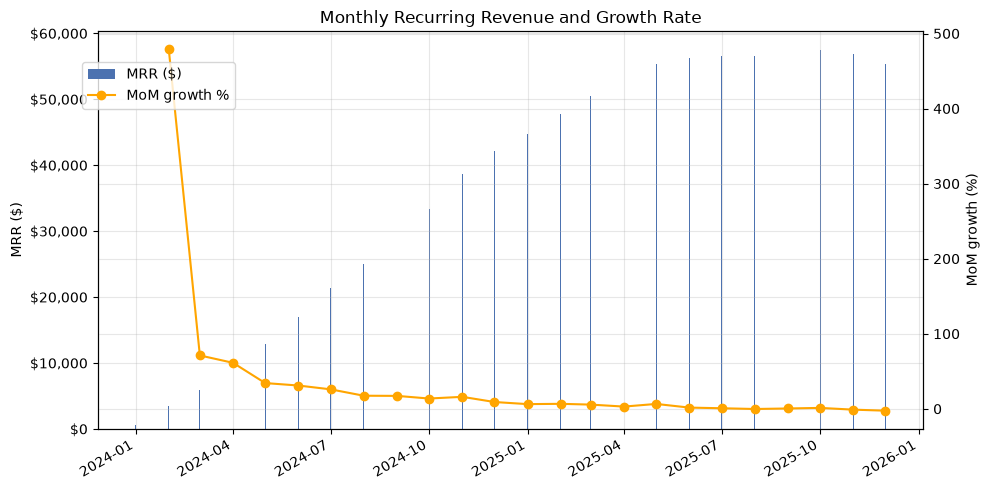

In [4]:
fig, ax1 = plt.subplots()
ax1.bar(mrr.index, mrr["mrr"], color="#4C72B0", label="MRR ($)")
ax1.set_ylabel("MRR ($)")
ax1.set_title("Monthly Recurring Revenue and Growth Rate")
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))

ax2 = ax1.twinx()
ax2.plot(mrr.index, mrr["mom_growth_pct"], color="orange", marker="o", label="MoM growth %")
ax2.set_ylabel("MoM growth (%)")
fig.autofmt_xdate()
fig.legend(loc="upper left", bbox_to_anchor=(0.08, 0.88))
plt.tight_layout()
plt.savefig("charts/mrr_growth.png", dpi=120)
plt.show()

## 3. Churn rate over time

Churn rate = customers who cancelled that month ÷ customers active at the start of the month.

In [5]:
active_by_month = usage.groupby("month")["customer_id"].nunique().rename("active_customers")
churned_by_month = (
    subscriptions.dropna(subset=["end_date"])
    .groupby("end_date")["customer_id"]
    .nunique()
    .rename("churned_customers")
)

churn = pd.concat([active_by_month, churned_by_month], axis=1).fillna(0)
churn["churn_rate_pct"] = (churn["churned_customers"] / churn["active_customers"] * 100).round(2)
churn.tail(12)

,active_customers,churned_customers,churn_rate_pct
2025-01-01,382,18.0,4.71
2025-02-01,395,9.0,2.28
2025-03-01,420,7.0,1.67
2025-04-01,435,8.0,1.84
2025-05-01,449,21.0,4.68
2025-06-01,443,18.0,4.06
2025-07-01,440,11.0,2.50
2025-08-01,439,16.0,3.64
2025-09-01,427,15.0,3.51
2025-10-01,416,18.0,4.33


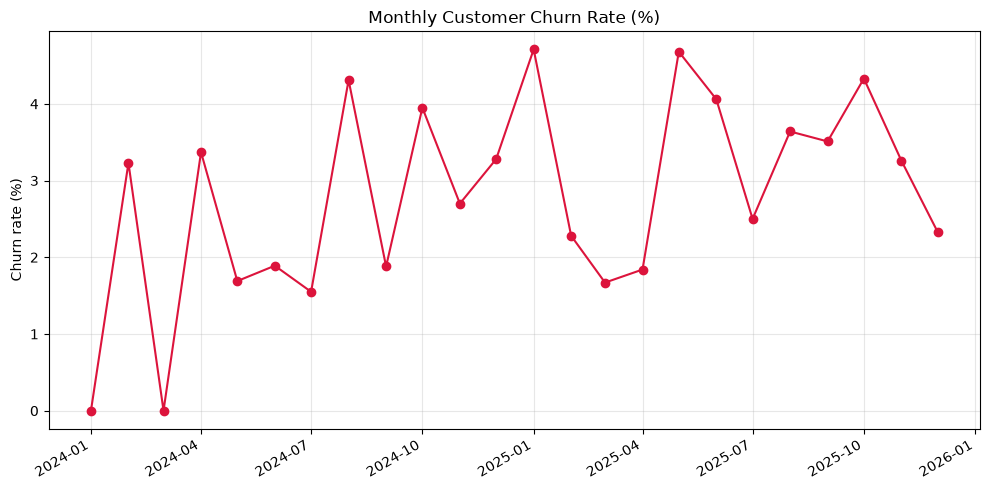

Average monthly churn rate: 2.78%
Implied average customer lifetime: 36.0 months


In [6]:
fig, ax = plt.subplots()
ax.plot(churn.index, churn["churn_rate_pct"], color="crimson", marker="o")
ax.set_title("Monthly Customer Churn Rate (%)")
ax.set_ylabel("Churn rate (%)")
fig.autofmt_xdate()
plt.tight_layout()
plt.savefig("charts/churn_rate.png", dpi=120)
plt.show()

avg_churn = churn["churn_rate_pct"].mean()
print(f"Average monthly churn rate: {avg_churn:.2f}%")
print(f"Implied average customer lifetime: {1/(avg_churn/100):.1f} months")

## 4. Revenue by plan, industry, and acquisition channel

In [7]:
plan_summary = (
    subscriptions.groupby("plan")
    .agg(total_subs=("subscription_id", "count"),
         active_now=("status", lambda s: (s == "active").sum()),
         avg_mrr=("mrr", "mean"))
    .round(2)
    .sort_values("avg_mrr", ascending=False)
)
plan_summary

,total_subs,active_now,avg_mrr
plan,,,
Enterprise,159,133,299.0
Growth,192,124,99.0
Starter,249,120,29.0


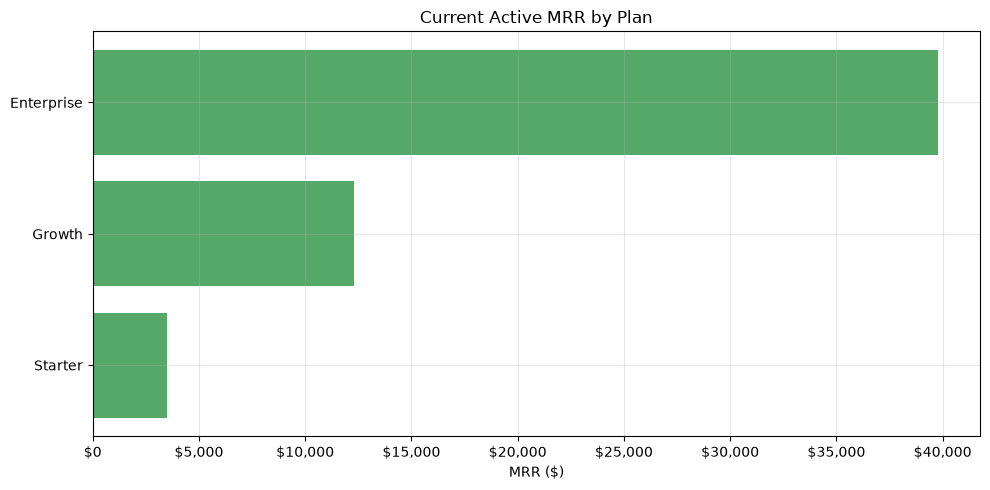

In [8]:
fig, ax = plt.subplots()
plan_revenue = subscriptions[subscriptions.status == "active"].groupby("plan")["mrr"].sum().sort_values()
ax.barh(plan_revenue.index, plan_revenue.values, color="#55A868")
ax.set_title("Current Active MRR by Plan")
ax.set_xlabel("MRR ($)")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("charts/mrr_by_plan.png", dpi=120)
plt.show()

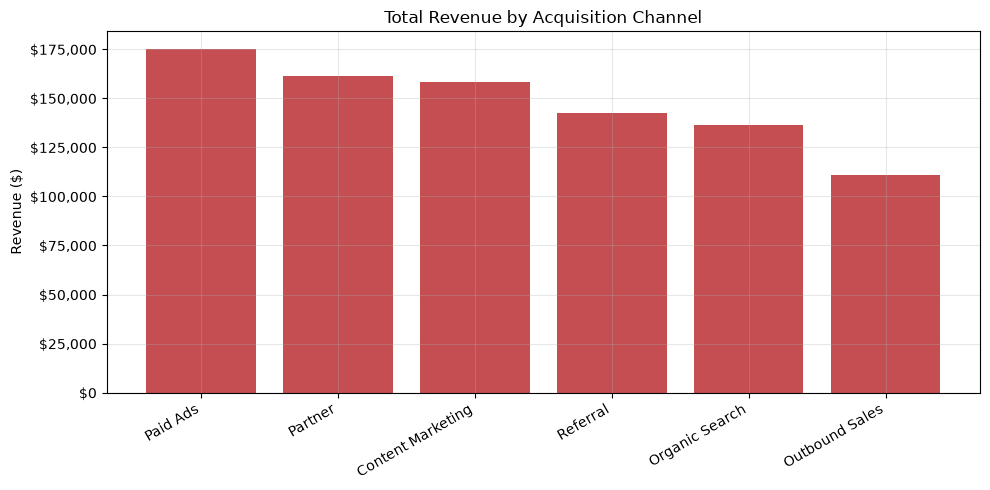

In [9]:
channel_revenue = (
    payments[payments.status == "paid"]
    .merge(customers[["customer_id", "acquisition_channel"]], on="customer_id")
    .groupby("acquisition_channel")["amount"].sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots()
ax.bar(channel_revenue.index, channel_revenue.values, color="#C44E52")
ax.set_title("Total Revenue by Acquisition Channel")
ax.set_ylabel("Revenue ($)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("charts/revenue_by_channel.png", dpi=120)
plt.show()

## 5. Cohort retention analysis

For each signup-month cohort, what % of customers are still active N months later?

In [10]:
cohort_map = customers.set_index("customer_id")["signup_date"].dt.to_period("M")
usage["cohort_month"] = usage["customer_id"].map(cohort_map)
usage["usage_month_p"] = usage["month"].dt.to_period("M")
usage["months_since_signup"] = (usage["usage_month_p"] - usage["cohort_month"]).apply(lambda x: x.n)

cohort_counts = (
    usage.groupby(["cohort_month", "months_since_signup"])["customer_id"]
    .nunique()
    .unstack(fill_value=0)
)
cohort_size = cohort_counts[0]
retention = cohort_counts.divide(cohort_size, axis=0).round(3) * 100
retention.iloc[:12, :12]

months_since_signup,0,1,2,3,4,5,6,7,8,9,10,11
cohort_month,,,,,,,,,,,,
2024-01,100.0,100.0,90.0,90.0,80.0,80.0,80.0,80.0,80.0,80.0,80.0,80.0
2024-02,100.0,100.0,100.0,95.2,95.2,95.2,95.2,85.7,81.0,76.2,71.4,71.4
2024-03,100.0,100.0,96.6,96.6,96.6,93.1,82.8,82.8,75.9,75.9,72.4,65.5
2024-04,100.0,100.0,93.3,90.0,90.0,90.0,86.7,86.7,86.7,76.7,66.7,66.7
2024-05,100.0,100.0,93.8,93.8,90.6,90.6,84.4,81.2,71.9,71.9,71.9,71.9
2024-06,100.0,100.0,95.3,88.4,86.0,83.7,83.7,79.1,74.4,72.1,72.1,67.4
2024-07,100.0,100.0,97.3,94.6,89.2,86.5,83.8,78.4,75.7,75.7,75.7,67.6
2024-08,100.0,100.0,97.6,92.9,88.1,88.1,88.1,88.1,83.3,81.0,76.2,76.2
2024-09,100.0,100.0,95.5,90.9,88.6,81.8,81.8,81.8,77.3,75.0,70.5,70.5


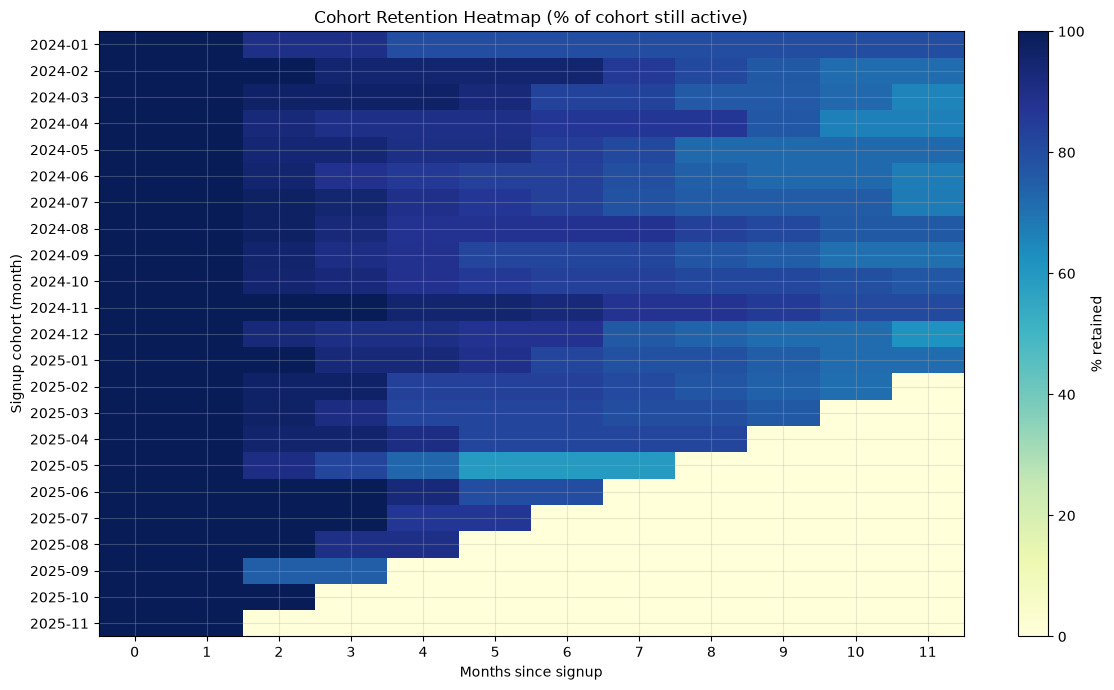

In [11]:
fig, ax = plt.subplots(figsize=(12, 7))
im = ax.imshow(retention.iloc[:, :12], cmap="YlGnBu", aspect="auto", vmin=0, vmax=100)
ax.set_xticks(range(12))
ax.set_yticks(range(len(retention)))
ax.set_yticklabels([str(i) for i in retention.index])
ax.set_xlabel("Months since signup")
ax.set_ylabel("Signup cohort (month)")
ax.set_title("Cohort Retention Heatmap (% of cohort still active)")
plt.colorbar(im, ax=ax, label="% retained")
plt.tight_layout()
plt.savefig("charts/cohort_retention.png", dpi=120)
plt.show()

## 6. Estimated Customer Lifetime Value (LTV) by plan

Simple approximation: `LTV = Average MRR / Monthly churn rate` for that plan.

In [12]:
plan_churn = (
    subscriptions.groupby("plan")
    .agg(total=("subscription_id", "count"),
         churned=("status", lambda s: (s == "churned").sum()))
)
plan_churn["churn_rate"] = plan_churn["churned"] / plan_churn["total"]
plan_churn["avg_mrr"] = subscriptions.groupby("plan")["mrr"].mean()
plan_churn["estimated_ltv"] = (plan_churn["avg_mrr"] / plan_churn["churn_rate"]).round(2)
plan_churn.round(3)

,total,churned,churn_rate,avg_mrr,estimated_ltv
plan,,,,,
Enterprise,159,26,0.164,299.0,1828.50
Growth,192,68,0.354,99.0,279.53
Starter,249,129,0.518,29.0,55.98


## 7. At-risk active customers (low logins + negative NPS)

A simple rule-based flag a retention/CS team could act on today.

In [13]:
latest_month = usage["month"].max()
latest_usage = usage[usage["month"] == latest_month]

at_risk = (
    latest_usage[(latest_usage.logins < 5) & (latest_usage.nps_score < 0)]
    .merge(customers[["customer_id", "company_name"]], on="customer_id")
    .merge(subscriptions[subscriptions.status == "active"][["customer_id", "plan", "mrr"]], on="customer_id")
    .sort_values("mrr", ascending=False)
    [["customer_id", "company_name", "plan", "mrr", "logins", "nps_score"]]
)
print(f"{len(at_risk)} active customers flagged as at-risk, representing "
      f"${at_risk['mrr'].sum():,.0f} in MRR")
at_risk.head(15)

8 active customers flagged as at-risk, representing $302 in MRR


,customer_id,company_name,plan,mrr,logins,nps_score
7,CUST0559,Gross-Valencia,Growth,99,2,-11
0,CUST0094,Newton and Sons,Starter,29,4,-21
2,CUST0124,"Joyce, Wilson and Lam",Starter,29,2,-9
1,CUST0101,Figueroa PLC,Starter,29,3,-1
3,CUST0315,"Becker, Taylor and Davis",Starter,29,3,-5
4,CUST0383,"Austin, Day and Johnson",Starter,29,3,-26
5,CUST0481,Brown-Copeland,Starter,29,3,-5
6,CUST0491,"Fuller, Ingram and Moss",Starter,29,4,-10


## 8. Export a summary for the Excel workbook

Writes CSVs that `SaaS_Dashboard.xlsx` uses. Re-run this cell any time the analysis above changes.

In [14]:
import os
os.makedirs("exports", exist_ok=True)

mrr.reset_index().rename(columns={"index": "month"}).to_csv("exports/mrr_by_month.csv", index=False)
churn.reset_index().rename(columns={"index": "month"}).to_csv("exports/churn_by_month.csv", index=False)
plan_summary.reset_index().to_csv("exports/plan_summary.csv", index=False)
channel_revenue.reset_index().to_csv("exports/channel_revenue.csv", index=False)
plan_churn.reset_index().to_csv("exports/ltv_by_plan.csv", index=False)
at_risk.to_csv("exports/at_risk_customers.csv", index=False)

print("Exported summary CSVs to ./exports/")
os.listdir("exports")

Exported summary CSVs to ./exports/


['at_risk_customers.csv',
 'channel_revenue.csv',
 'churn_by_month.csv',
 'ltv_by_plan.csv',
 'mrr_by_month.csv',
 'plan_summary.csv']

## Key takeaways (fill in / adjust after you review the charts above)

- **MRR trend:** revenue has grown steadily as new cohorts sign up faster than existing customers churn.
- **Churn:** Starter-plan customers churn noticeably faster than Growth/Enterprise — engagement (logins, NPS) is a leading indicator.
- **LTV:** Enterprise customers are worth several times more over their lifetime than Starter customers, even though there are fewer of them.
- **Channels:** compare revenue-per-customer across acquisition channels to see which channel brings in the highest-value customers, not just the most customers.
- **Action:** the at-risk list in section 7 is a ready-made outreach list for a customer-success team.
